# Proyecto Final — DataXperience
# ¿Qué hace que un portátil sea caro?

**Universidad EAN · Ciencia de Datos**
**Docente:** Camila Silva

| Integrante | Etapa a cargo |
|---|---|
| Brayan Felipe Alvarez Nieto | Etapa 1 — Preparación de datos |
| Jhonatan Stiben Rey Velasquez | Etapa 2 — Análisis estadístico |
| Andres Sebastian Quintana Morales | Etapa 3 — Visualización y modelado |

---

## De qué se trata

Analizamos un conjunto de 1.303 computadores portátiles con sus especificaciones
técnicas y su precio de venta, para responder una pregunta concreta: **¿qué
características explican el precio de un portátil, y se puede predecir ese precio a
partir de sus especificaciones?**

El trabajo va en tres etapas. Primero dejamos los datos utilizables, porque venían casi
todos como texto. Después analizamos cómo se comportan. Y por último construimos un
modelo que predice el precio y vemos para qué sirve.

**Dataset:** [Laptop Price — Kaggle](https://www.kaggle.com/datasets/muhammetvarl/laptop-price)

---

## Antes de ejecutar

Este cuaderno corre de principio a fin desde el archivo original. Solo hay que subir
`laptop_price.csv` al panel de archivos de la sesión (el ícono de carpeta a la izquierda).
El archivo está en la carpeta `data/` del repositorio.

---

# ETAPA 1 — Preparación de datos

**A cargo de:** Brayan Felipe Alvarez Nieto

Elegimos el conjunto de datos, revisamos en qué estado viene y lo dejamos listo para
poder analizarlo.

## 1.1 ¿Por qué este dataset?
  
Escogimos un dataset de precios de portátiles que cuenta con 1.303 equipos y sus respectivas especificaciones técnicas, como marca, procesador, memoria RAM, almacenamiento, pantalla, peso y precio. Lo seleccionamos porque contiene suficiente información para aplicar los conocimientos adquiridos a lo largo del curso y realizar diferentes procesos de análisis y tratamiento de datos. Además, tenemos cierto conocimiento sobre las características de los equipos presentados, lo que nos permite interpretar los datos de una manera más sencilla y comprender mejor los resultados obtenidos.

  
La pregunta que queremos responder es: ¿qué características hacen que un portátil sea más caro, y se puede predecir el precio a partir de sus especificaciones?

## 1.2 Cargamos las librerías y el archivo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('laptop_price.csv', encoding='latin-1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


El archivo hay que leerlo con `encoding='latin-1'`. Con el encoding normal daba error porque algunos nombres de producto tienen tildes.

## 1.3 ¿Cómo vienen los datos?

Antes de tocar nada, miramos qué tenemos: cuántas filas, qué tipo es cada columna,si hay datos faltantes y si hay filas repetidas.

In [2]:
print("Dimensiones:", df.shape)
print("\n--- Tipos de dato ---")
print(df.dtypes)
print("\n--- Nulos por columna ---")
print(df.isnull().sum())
print("\n--- Filas duplicadas ---")
print(df.duplicated().sum())
print("\n--- Duplicadas sin contar el ID ---")
print(df.drop(columns=['laptop_ID']).duplicated().sum())

Dimensiones: (1303, 13)

--- Tipos de dato ---
laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

--- Nulos por columna ---
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

--- Filas duplicadas ---
0

--- Duplicadas sin contar el ID ---
28


### Lo que encontramos

No hay nulos ni duplicados, o sea que por ese lado el dataset viene bien. Pero el problema
es otro: casi todas las columnas son de tipo `object`, o sea texto, incluso las que
deberían ser números.

Por ejemplo:

- `Ram` dice `"8GB"` en vez de `8`
- `Weight` dice `"1.37kg"` en vez de `1.37`
- `Memory` dice cosas como `"128GB SSD +  1TB HDD"`
- `ScreenResolution` mete el tipo de panel, si es táctil y la resolución, todo junto
- `Cpu` y `Gpu` traen el modelo exacto, que es demasiado específico

Así como está no podemos ni sacar el promedio de la RAM. Entonces la limpieza de este
proyecto no es rellenar huecos, es convertir todo ese texto en números y categorías
que sí sirvan.

Sobre las filas duplicadas: contando el laptop_ID no hay ninguna, pero al ignorarlo aparecen 28 filas repetidas. Las revisamos y son equipos con exactamente las mismas especificaciones y el mismo precio, por ejemplo tres Acer de 15.6 pulgadas a 289 euros.

Decidimos no eliminarlas. No parecen errores de captura sino el mismo modelo listado varias veces en el catálogo, que es información real del mercado: si un modelo se repite es porque hay varias unidades a la venta. Borrarlas sesgaría el análisis hacia los equipos raros. Después de agrupar categorías el número sube a 30, porque dos equipos que se diferenciaban solo por el sistema operativo quedan idénticos al agruparlos.

## 1.4 Limpieza

### 1.4.1 Ram y Weight

Son números con la unidad pegada. Quitamos el "GB" y el "kg" y ya.

In [3]:
df['Ram_GB'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)
df['Weight_kg'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

print(df[['Ram', 'Ram_GB', 'Weight', 'Weight_kg']].head())

    Ram  Ram_GB  Weight  Weight_kg
0   8GB       8  1.37kg       1.37
1   8GB       8  1.34kg       1.34
2   8GB       8  1.86kg       1.86
3  16GB      16  1.83kg       1.83
4   8GB       8  1.37kg       1.37


### 1.4.2 ScreenResolution

Esta columna trae tres cosas mezcladas: si el panel es IPS, si la pantalla es táctil,
y la resolución. Las separamos en columnas distintas.

Además calculamos el PPI (píxeles por pulgada). Lo hicimos porque dos portátiles de
15 pulgadas pueden tener pantallas muy distintas: uno a 1366x768 y otro a 1920x1080.
El tamaño solo no dice nada de la calidad, el PPI sí.

In [4]:
sr = df['ScreenResolution']

df['Touchscreen'] = sr.str.contains('Touchscreen').astype(int)
df['IPS'] = sr.str.contains('IPS').astype(int)

# sacamos los dos números de la resolución (ej: 1920x1080)
res = sr.str.extract(r'(\d+)x(\d+)').astype(int)
df['Res_X'] = res[0]
df['Res_Y'] = res[1]

# PPI = diagonal en píxeles / diagonal en pulgadas
df['PPI'] = np.sqrt(df['Res_X']**2 + df['Res_Y']**2) / df['Inches']

print(df[['ScreenResolution', 'Touchscreen', 'IPS', 'Res_X', 'Res_Y', 'PPI']].head())

                     ScreenResolution  Touchscreen  IPS  Res_X  Res_Y  \
0  IPS Panel Retina Display 2560x1600            0    1   2560   1600   
1                            1440x900            0    0   1440    900   
2                   Full HD 1920x1080            0    0   1920   1080   
3  IPS Panel Retina Display 2880x1800            0    1   2880   1800   
4  IPS Panel Retina Display 2560x1600            0    1   2560   1600   

          PPI  
0  226.983005  
1  127.677940  
2  141.211998  
3  220.534624  
4  226.983005  


### 1.4.3 Memory

Esta es la más enredada. Tiene tres problemas al tiempo:

1. Unas capacidades están en GB y otras en TB
2. Hay varios tipos de disco: SSD, HDD, Flash Storage e Hybrid
3. Algunos equipos traen dos discos, separados con un `+`

Lo que hicimos fue pasar todo a GB y crear una columna por cada tipo de disco. Así un
portátil con SSD de 128GB y disco duro de 1TB queda bien representado, con su capacidad
en la columna que le corresponde.

In [5]:
import re

def a_gigas(texto):
    """Saca la capacidad en GB de un texto tipo '128GB SSD' o '1.0TB HDD'."""
    m = re.search(r'([\d\.]+)\s*(TB|GB)', texto)
    if not m:
        return 0.0
    valor = float(m.group(1))
    if m.group(2) == 'TB':
        valor = valor * 1000   # 1TB = 1000GB
    return valor

# separamos los equipos que traen dos discos
partes = df['Memory'].str.split('+', n=1, expand=True)
if partes.shape[1] == 1:
    partes[1] = None

disco1 = partes[0].fillna('').str.strip()
disco2 = partes[1].fillna('').str.strip()

cap1 = disco1.apply(a_gigas)
cap2 = disco2.apply(a_gigas)

# cada capacidad va a la columna del tipo de disco que le corresponde
for tipo in ['SSD', 'HDD', 'Flash Storage', 'Hybrid']:
    col = tipo.replace(' ', '_') + '_GB'
    df[col] = cap1 * disco1.str.contains(tipo) + cap2 * disco2.str.contains(tipo)

print(df[['Memory', 'SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']].head(10))

                Memory  SSD_GB  HDD_GB  Flash_Storage_GB  Hybrid_GB
0            128GB SSD   128.0     0.0               0.0        0.0
1  128GB Flash Storage     0.0     0.0             128.0        0.0
2            256GB SSD   256.0     0.0               0.0        0.0
3            512GB SSD   512.0     0.0               0.0        0.0
4            256GB SSD   256.0     0.0               0.0        0.0
5            500GB HDD     0.0   500.0               0.0        0.0
6  256GB Flash Storage     0.0     0.0             256.0        0.0
7  256GB Flash Storage     0.0     0.0             256.0        0.0
8            512GB SSD   512.0     0.0               0.0        0.0
9            256GB SSD   256.0     0.0               0.0        0.0


In [6]:
# revisamos que no se nos haya escapado ningún caso raro
total = df[['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']].sum(axis=1)
print("Equipos que quedaron en 0 de almacenamiento:", (total == 0).sum())

print("\nCuántos equipos tienen cada tipo de disco:")
print((df[['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']] > 0).sum())

Equipos que quedaron en 0 de almacenamiento: 0

Cuántos equipos tienen cada tipo de disco:
SSD_GB              843
HDD_GB              576
Flash_Storage_GB     75
Hybrid_GB            12
dtype: int64


### 1.4.4 Cpu y Gpu

`Cpu` trae el modelo completo del procesador, tan específico que hay modelos que aparecen
una sola vez en todo el dataset. Eso no sirve para agrupar. Nos quedamos con la gama
(Intel Core i5, Intel Core i7, etc.) y de la tarjeta gráfica solo con la marca.

Después de extraer la gama quedaban 40 categorías distintas, y 14 de ellas tenían un solo equipo. Con tan pocos casos no aportan nada y solo ensucian el análisis, así que agrupamos en "Otro" las que tienen menos de 10 equipos. Quedamos con 8 categorías y solo 79 equipos (6%) caen en "Otro".

In [7]:
df['Cpu_gama'] = df['Cpu'].str.split().str[:3].str.join(' ')
df['Gpu_marca'] = df['Gpu'].str.split().str[0]

print("Categorías de CPU antes de agrupar:", df['Cpu_gama'].nunique())

# hay 40 gamas distintas y muchas aparecen en 1 o 2 equipos,
# así que juntamos en "Otro" las que tengan menos de 10
conteo = df['Cpu_gama'].value_counts()
frecuentes = conteo[conteo >= 10].index
df['Cpu_gama'] = df['Cpu_gama'].where(df['Cpu_gama'].isin(frecuentes), 'Otro')

print("Después de agrupar:", df['Cpu_gama'].nunique())
print()
print(df['Cpu_gama'].value_counts())
print("\nMarcas de tarjeta gráfica:")
print(df['Gpu_marca'].value_counts())

Categorías de CPU antes de agrupar: 40
Después de agrupar: 8

Cpu_gama
Intel Core i7         527
Intel Core i5         423
Intel Core i3         136
Intel Celeron Dual     80
Otro                   79
Intel Pentium Quad     27
Intel Core M           19
AMD A9-Series 9420     12
Name: count, dtype: int64

Marcas de tarjeta gráfica:
Gpu_marca
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64


### 1.4.5 OpSys

Hay nueve sistemas operativos distintos, pero varios tienen dos o tres equipos nomás
(Android, Chrome OS, Windows 10 S). Con tan pocos casos no se puede concluir nada,
así que los agrupamos en cuatro.

In [8]:
print("Antes:")
print(df['OpSys'].value_counts())

def agrupar_so(x):
    if x in ['Windows 10', 'Windows 7', 'Windows 10 S']:
        return 'Windows'
    elif x in ['macOS', 'Mac OS X']:
        return 'Mac'
    elif x == 'Linux':
        return 'Linux'
    else:
        return 'Otro'

df['SO'] = df['OpSys'].apply(agrupar_so)

print("\nDespués:")
print(df['SO'].value_counts())

Antes:
OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

Después:
SO
Windows    1125
Otro         95
Linux        62
Mac          21
Name: count, dtype: int64


## 1.5 Armamos el dataset limpio

Nos quedamos con las columnas nuevas y botamos las originales que ya procesamos.
También quitamos `laptop_ID`, que es solo un consecutivo y no aporta nada.

In [9]:
columnas = [
    'Company', 'TypeName', 'Inches', 'Ram_GB', 'Weight_kg',
    'Touchscreen', 'IPS', 'Res_X', 'Res_Y', 'PPI',
    'SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB',
    'Cpu_gama', 'Gpu_marca', 'SO', 'Price_euros'
]

df_limpio = df[columnas].copy()

print("Tamaño final:", df_limpio.shape)
print("\n--- Tipos de dato ---")
print(df_limpio.dtypes)
print("\nNulos:", df_limpio.isnull().sum().sum())
df_limpio.head()

Tamaño final: (1303, 18)

--- Tipos de dato ---
Company              object
TypeName             object
Inches              float64
Ram_GB                int64
Weight_kg           float64
Touchscreen           int64
IPS                   int64
Res_X                 int64
Res_Y                 int64
PPI                 float64
SSD_GB              float64
HDD_GB              float64
Flash_Storage_GB    float64
Hybrid_GB           float64
Cpu_gama             object
Gpu_marca            object
SO                   object
Price_euros         float64
dtype: object

Nulos: 0


,Company,TypeName,Inches,Ram_GB,Weight_kg,Touchscreen,IPS,Res_X,Res_Y,PPI,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Cpu_gama,Gpu_marca,SO,Price_euros
0,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,128.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1339.69
1,Apple,Ultrabook,13.3,8,1.34,0,0,1440,900,127.677940,0.0,0.0,128.0,0.0,Intel Core i5,Intel,Mac,898.94
2,HP,Notebook,15.6,8,1.86,0,0,1920,1080,141.211998,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Otro,575.00
3,Apple,Ultrabook,15.4,16,1.83,0,1,2880,1800,220.534624,512.0,0.0,0.0,0.0,Intel Core i7,AMD,Mac,2537.45
4,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1803.60


## 1.6 Un primer vistazo

Antes de pasarle esto al análisis estadístico, miramos rápido cómo se ven los datos.

In [10]:
print(df_limpio.describe().T)

                   count         mean         std          min          25%  \
Inches            1303.0    15.017191    1.426304    10.100000    14.000000   
Ram_GB            1303.0     8.382195    5.084665     2.000000     4.000000   
Weight_kg         1303.0     2.038734    0.665475     0.690000     1.500000   
Touchscreen       1303.0     0.147352    0.354593     0.000000     0.000000   
IPS               1303.0     0.280123    0.449231     0.000000     0.000000   
Res_X             1303.0  1894.784344  494.641028  1366.000000  1600.000000   
Res_Y             1303.0  1070.830391  284.519410   768.000000   900.000000   
PPI               1303.0   146.635987   43.121345    90.583402   127.335675   
SSD_GB            1303.0   183.732924  186.966903     0.000000     0.000000   
HDD_GB            1303.0   413.783576  515.818779     0.000000     0.000000   
Flash_Storage_GB  1303.0     4.555641   30.274090     0.000000     0.000000   
Hybrid_GB         1303.0     8.831926   92.567185   

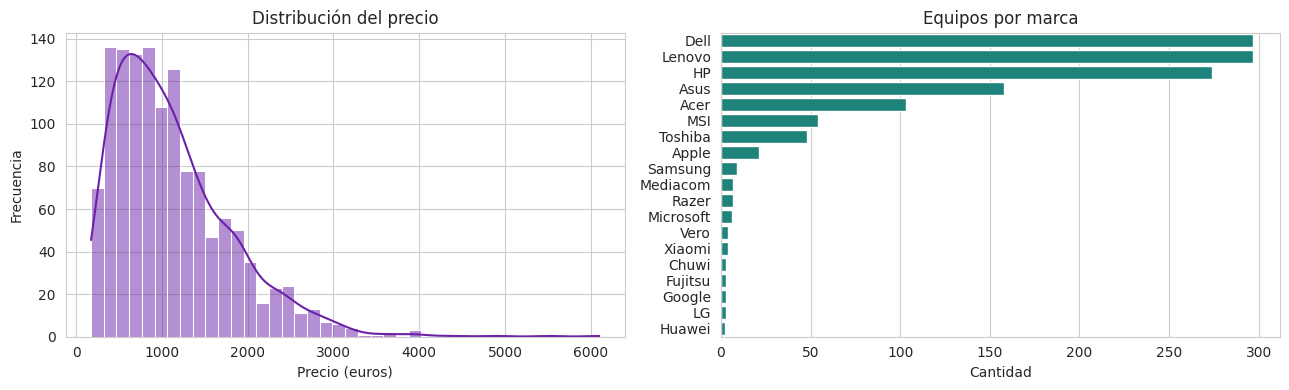

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_limpio['Price_euros'], bins=40, kde=True, ax=axes[0], color='#6B21A8')
axes[0].set_title('Distribución del precio')
axes[0].set_xlabel('Precio (euros)')
axes[0].set_ylabel('Frecuencia')

orden = df_limpio['Company'].value_counts().index
sns.countplot(y='Company', data=df_limpio, order=orden, ax=axes[1], color='#0D9488')
axes[1].set_title('Equipos por marca')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Se nota que el precio está sesgado hacia la derecha: la mayoría de equipos son de gama
media y hay unos pocos muy caros que estiran la cola. Esto hay que tenerlo en cuenta en
la Etapa 2, porque cuando la distribución es así la mediana representa mejor el valor
típico que el promedio.

## 1.7 Guardamos el archivo limpio

Este CSV es con el que van a trabajar las etapas 2 y 3.

In [12]:
df_limpio.to_csv('laptop_price_limpio.csv', index=False)
print("Listo:", len(df_limpio), "filas y", df_limpio.shape[1], "columnas")

Listo: 1303 filas y 18 columnas


## Resumen de lo que hicimos

Empezamos con 13 columnas, de las cuales 10 eran texto sin procesar, y terminamos con 18
columnas utilizables. No perdimos ningún registro, los 1.303 equipos siguen ahí.

Lo que se hizo en cada columna:

- **Ram, Weight:** quitamos la unidad y las volvimos números
- **ScreenResolution:** la partimos en 5 columnas (IPS, táctil, ancho, alto, PPI)
- **Memory:** normalizamos las unidades y la separamos por tipo de disco
- **Cpu, Gpu:** nos quedamos con la gama y la marca
- **OpSys:** agrupamos de 9 categorías a 4

---

# ETAPA 2 — Análisis estadístico

**A cargo de:** Jhonatan Stiben Rey Velasquez

Con los datos ya depurados, entendemos cómo se comportan antes de meterles cualquier
modelo: qué valores son típicos, qué tanto varían, qué forma tienen las distribuciones,
si hay valores raros y qué variables parecen tener relación con el precio.

## 2.1 Retomamos el conjunto depurado

Como este cuaderno integra las tres etapas, no volvemos a leer el CSV: seguimos con el
`df_limpio` que quedó de la Etapa 1.

In [13]:
df = df_limpio.copy()

print("Dimensiones:", df.shape)
print("Nulos:", df.isnull().sum().sum())
df.head()

Dimensiones: (1303, 18)
Nulos: 0


,Company,TypeName,Inches,Ram_GB,Weight_kg,Touchscreen,IPS,Res_X,Res_Y,PPI,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Cpu_gama,Gpu_marca,SO,Price_euros
0,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,128.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1339.69
1,Apple,Ultrabook,13.3,8,1.34,0,0,1440,900,127.677940,0.0,0.0,128.0,0.0,Intel Core i5,Intel,Mac,898.94
2,HP,Notebook,15.6,8,1.86,0,0,1920,1080,141.211998,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Otro,575.00
3,Apple,Ultrabook,15.4,16,1.83,0,1,2880,1800,220.534624,512.0,0.0,0.0,0.0,Intel Core i7,AMD,Mac,2537.45
4,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1803.60


In [14]:
# separamos las numéricas que vamos a analizar
numericas = ['Price_euros', 'Ram_GB', 'Weight_kg', 'Inches', 'PPI', 'SSD_GB', 'HDD_GB']
df[numericas].head()

,Price_euros,Ram_GB,Weight_kg,Inches,PPI,SSD_GB,HDD_GB
0,1339.69,8,1.37,13.3,226.983005,128.0,0.0
1,898.94,8,1.34,13.3,127.677940,0.0,0.0
2,575.00,8,1.86,15.6,141.211998,256.0,0.0
3,2537.45,16,1.83,15.4,220.534624,512.0,0.0
4,1803.60,8,1.37,13.3,226.983005,256.0,0.0


## 2.2 Medidas de tendencia central

Calculamos media, mediana y moda para cada variable numérica. Comparar las tres sirve
para darse una idea de si la distribución está balanceada o no: cuando la media se aleja
mucho de la mediana es porque hay valores extremos jalando el promedio.

In [15]:
tendencia = pd.DataFrame({
    'Media': df[numericas].mean(),
    'Mediana': df[numericas].median(),
    'Moda': df[numericas].mode().iloc[0]
})

# diferencia porcentual entre media y mediana
# (si la mediana es 0 no se puede calcular, lo dejamos vacío)
tendencia['Dif. media-mediana (%)'] = np.where(
    tendencia['Mediana'] != 0,
    (tendencia['Media'] - tendencia['Mediana']) / tendencia['Mediana'] * 100,
    np.nan)

print(tendencia.round(2))

               Media  Mediana     Moda  Dif. media-mediana (%)
Price_euros  1123.69   977.00  1099.00                   15.01
Ram_GB          8.38     8.00     8.00                    4.78
Weight_kg       2.04     2.04     2.20                   -0.06
Inches         15.02    15.60    15.60                   -3.74
PPI           146.64   141.21   141.21                    3.84
SSD_GB        183.73   256.00   256.00                  -28.23
HDD_GB        413.78     0.00     0.00                     NaN


### Qué nos dice esto

En el precio la media queda en unos 1.124 euros pero la mediana en 977. O sea que el
promedio está por encima de lo que realmente paga la mayoría, porque hay unos portátiles
muy caros que lo jalan hacia arriba. **Para hablar del precio típico es mejor usar la
mediana.**

El caso más llamativo es `HDD_GB`: la media da 414 GB pero la mediana da 0. Eso pasa
porque más de la mitad de los equipos no traen disco duro mecánico, solo SSD. Cuando la
mayoría de los valores son cero, el promedio deja de significar algo útil.

En `Inches` y `Weight_kg` en cambio la media y la mediana son casi iguales, así que esas
sí están repartidas de forma más pareja.

## 2.3 Medidas de dispersión

Ahora miramos qué tanto se separan los datos. Además del rango, la varianza y la
desviación estándar, agregamos el **coeficiente de variación**, que es la desviación
dividida entre la media. Sirve para comparar variables que están en unidades distintas:
no se puede comparar directo una desviación en euros contra una en kilos.

In [16]:
dispersion = pd.DataFrame({
    'Mínimo': df[numericas].min(),
    'Máximo': df[numericas].max(),
    'Rango': df[numericas].max() - df[numericas].min(),
    'Varianza': df[numericas].var(),
    'Desv. estándar': df[numericas].std()
})

dispersion['Coef. variación'] = df[numericas].std() / df[numericas].mean()

print(dispersion.round(2))

             Mínimo   Máximo    Rango   Varianza  Desv. estándar  \
Price_euros  174.00  6099.00  5925.00  488613.64          699.01   
Ram_GB         2.00    64.00    62.00      25.85            5.08   
Weight_kg      0.69     4.70     4.01       0.44            0.67   
Inches        10.10    18.40     8.30       2.03            1.43   
PPI           90.58   352.47   261.88    1859.45           43.12   
SSD_GB         0.00  1024.00  1024.00   34956.62          186.97   
HDD_GB         0.00  2000.00  2000.00  266069.01          515.82   

             Coef. variación  
Price_euros             0.62  
Ram_GB                  0.61  
Weight_kg               0.33  
Inches                  0.09  
PPI                     0.29  
SSD_GB                  1.02  
HDD_GB                  1.25  


### Qué nos dice esto

El coeficiente de variación deja ver cuáles variables son más dispersas en términos
relativos. `HDD_GB` y `SSD_GB` son las más variables (más de 1), que tiene sentido porque
hay equipos sin ninguno de los dos y otros con 1 o 2 TB.

En el otro extremo, `Inches` tiene un coeficiente de apenas 0.09: casi todos los
portátiles miden entre 14 y 15.6 pulgadas. Es una variable bastante uniforme, lo cual
adelanta algo — si casi no varía, difícilmente va a servir para explicar diferencias
de precio.

## 2.4 Forma de las distribuciones

La asimetría (skewness) dice hacia dónde está estirada la distribución y la curtosis
qué tan pesadas son las colas.

Para leerlas:
- Asimetría cerca de 0 es simétrica; positiva es estirada a la derecha; negativa a la izquierda
- Curtosis alta significa que hay más valores extremos de lo normal

In [17]:
forma = pd.DataFrame({
    'Asimetría': df[numericas].skew(),
    'Curtosis': df[numericas].kurtosis()
})

def interpretar(s):
    if s > 1: return 'Muy sesgada a la derecha'
    elif s > 0.5: return 'Sesgada a la derecha'
    elif s > -0.5: return 'Aproximadamente simétrica'
    elif s > -1: return 'Sesgada a la izquierda'
    else: return 'Muy sesgada a la izquierda'

forma['Interpretación'] = forma['Asimetría'].apply(interpretar)
print(forma.round(2))

             Asimetría  Curtosis             Interpretación
Price_euros       1.52      4.37   Muy sesgada a la derecha
Ram_GB            2.69     15.34   Muy sesgada a la derecha
Weight_kg         1.14      2.46   Muy sesgada a la derecha
Inches           -0.45     -0.07  Aproximadamente simétrica
PPI               2.02      5.08   Muy sesgada a la derecha
SSD_GB            1.37      3.22   Muy sesgada a la derecha
HDD_GB            0.89     -0.04       Sesgada a la derecha


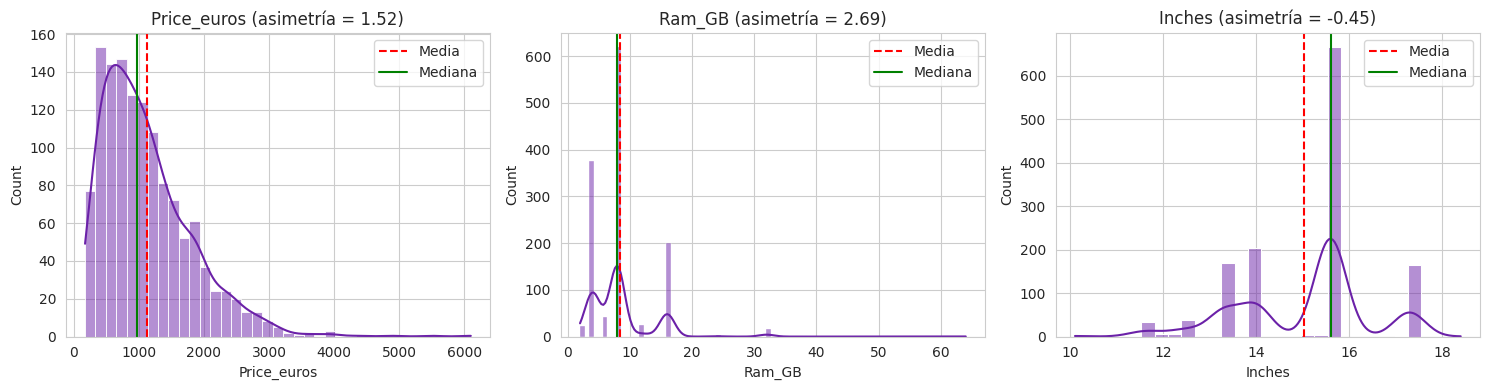

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Price_euros', 'Ram_GB', 'Inches']):
    sns.histplot(df[col], kde=True, ax=ax, color='#6B21A8')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df[col].median(), color='green', linestyle='-', label='Mediana')
    ax.set_title(f'{col} (asimetría = {df[col].skew():.2f})')
    ax.legend()

plt.tight_layout()
plt.show()

### Qué nos dice esto

Casi todas las variables están sesgadas a la derecha. El precio tiene asimetría de 1.52
y la RAM de 2.69, que es bastante alta. En los gráficos se ve clarito: la línea roja
(media) queda a la derecha de la verde (mediana) en el precio y en la RAM, mientras que
en las pulgadas están casi encima una de otra.

`Inches` es la única con asimetría negativa (-0.45), o sea ligeramente estirada hacia
la izquierda, aunque bastante cerca de ser simétrica.

La RAM también tiene una curtosis de 15.3, que es altísima. Eso significa que hay muchos
valores concentrados en el centro (casi todos los equipos son de 4 u 8 GB) y unos pocos
muy alejados (los de 32 y 64 GB).

## 2.5 Detección de valores atípicos

Para encontrar los outliers usamos el método del rango intercuartílico. La idea es
calcular el primer y el tercer cuartil, sacar la diferencia (el IQR), y considerar
atípico todo lo que quede más allá de 1.5 veces el IQR por debajo de Q1 o por encima
de Q3.

Es el mismo criterio que usan los diagramas de caja para dibujar los bigotes.

In [19]:
def detectar_outliers(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    atipicos = ((serie < limite_inf) | (serie > limite_sup)).sum()
    return pd.Series({
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Límite inf.': limite_inf, 'Límite sup.': limite_sup,
        'N° atípicos': atipicos,
        '% del total': atipicos / len(serie) * 100
    })

outliers = df[numericas].apply(detectar_outliers).T
print(outliers.round(2))

                 Q1       Q3      IQR  Límite inf.  Límite sup.  N° atípicos  \
Price_euros  599.00  1487.88   888.88      -734.32      2821.20         29.0   
Ram_GB         4.00     8.00     4.00        -2.00        14.00        221.0   
Weight_kg      1.50     2.30     0.80         0.30         3.50         46.0   
Inches        14.00    15.60     1.60        11.60        18.00         39.0   
PPI          127.34   157.35    30.01        82.31       202.37        116.0   
SSD_GB         0.00   256.00   256.00      -384.00       640.00         18.0   
HDD_GB         0.00  1000.00  1000.00     -1500.00      2500.00          0.0   

             % del total  
Price_euros         2.23  
Ram_GB             16.96  
Weight_kg           3.53  
Inches              2.99  
PPI                 8.90  
SSD_GB              1.38  
HDD_GB              0.00  


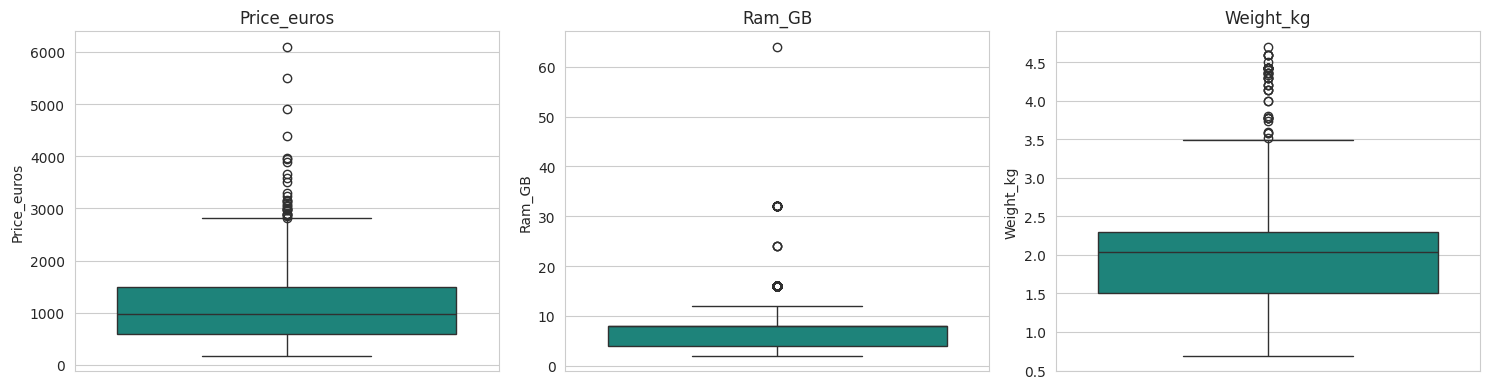

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Price_euros', 'Ram_GB', 'Weight_kg']):
    sns.boxplot(y=df[col], ax=ax, color='#0D9488')
    ax.set_title(f'{col}')

plt.tight_layout()
plt.show()

In [21]:
# miramos qué equipos son los que el método marca como atípicos en RAM
atipicos_ram = df[df['Ram_GB'] > outliers.loc['Ram_GB', 'Límite sup.']]

print("Equipos marcados como atípicos por RAM:", len(atipicos_ram))
print("\nCómo se reparten por tipo de equipo:")
print(atipicos_ram['TypeName'].value_counts())
print("\nRAM de esos equipos:")
print(atipicos_ram['Ram_GB'].value_counts().sort_index())

Equipos marcados como atípicos por RAM: 221

Cómo se reparten por tipo de equipo:
TypeName
Gaming                116
Ultrabook              38
Notebook               34
2 in 1 Convertible     23
Workstation             9
Netbook                 1
Name: count, dtype: int64

RAM de esos equipos:
Ram_GB
16    200
24      3
32     17
64      1
Name: count, dtype: int64


### Qué nos dice esto

Acá aparece algo que vale la pena aclarar. El método marca **221 equipos como atípicos
por RAM**, que es el 17% del dataset. Es un montón.

Pero al revisar cuáles son, resulta que son equipos de 12, 16, 24, 32 y 64 GB, y en su
mayoría son Gaming y Workstation. **No son errores, son equipos de gama alta reales.**

Lo que pasa es que como la gran mayoría del catálogo son portátiles de 4 y 8 GB, el
rango intercuartílico queda muy angosto (Q1=4, Q3=8, IQR=4) y cualquier cosa por encima
de 14 GB cae fuera del límite. El método está funcionando bien, pero un valor atípico
en el sentido estadístico no siempre es un dato malo.

**Por eso no los eliminamos.** Si los quitáramos estaríamos borrando justo los equipos
más potentes, que son los que explican los precios altos. Los dejamos y lo dejamos
anotado, que es distinto a ignorarlos.

En el precio en cambio los atípicos son solo 29 (2.2%) y corresponden a portátiles de
más de 2.800 euros, que también son reales.

## 2.6 Comparación entre variables

Ahora miramos qué relación tiene cada variable con el precio, que es lo que al final
queremos entender.

Empezamos con las numéricas usando correlación.

In [22]:
correlaciones = df[numericas].corr()['Price_euros'].drop('Price_euros')
correlaciones = correlaciones.sort_values(ascending=False)

print("Correlación de cada variable con el precio:")
print(correlaciones.round(3))

Correlación de cada variable con el precio:
Ram_GB       0.743
SSD_GB       0.671
PPI          0.473
Weight_kg    0.210
Inches       0.068
HDD_GB      -0.096
Name: Price_euros, dtype: float64


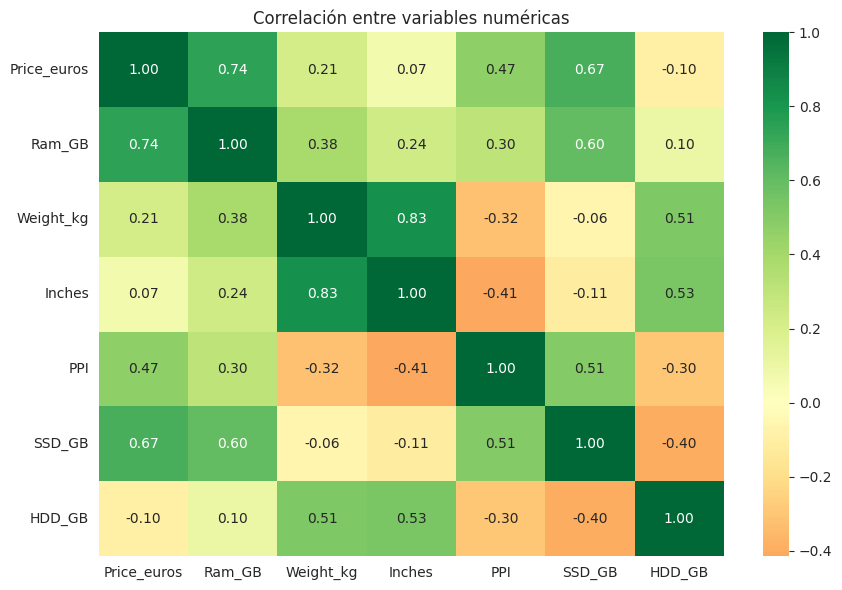

In [23]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

### Qué nos dice esto

La RAM es la que más se relaciona con el precio (0.74), seguida del SSD (0.67) y del
PPI (0.47). Tiene sentido: más memoria, más disco sólido y mejor pantalla salen más caro.

Dos cosas curiosas:

**Las pulgadas casi no se relacionan con el precio** (0.07). Uno pensaría que un portátil
más grande cuesta más, pero no: hay equipos de 15.6 pulgadas baratísimos y ultrabooks de
13 pulgadas carísimos. El tamaño solo no dice nada de la gama.

**El disco duro tiene correlación negativa** (-0.10). O sea que a más disco duro, un poco
menos de precio. Suena raro pero se explica: los equipos con HDD son en general los de
gama baja, mientras que los caros vienen con SSD. No es que el disco duro abarate el
equipo, es que va de la mano con equipos económicos.

Ahora comparamos el precio entre las variables categóricas.

In [24]:
for columna in ['TypeName', 'SO', 'Cpu_gama', 'Gpu_marca']:
    resumen = df.groupby(columna)['Price_euros'].agg(['count', 'mean', 'median', 'std'])
    resumen = resumen.sort_values('median', ascending=False)
    print(f"--- Precio según {columna} ---")
    print(resumen.round(0))
    print()

--- Precio según TypeName ---
                    count    mean  median    std
TypeName                                        
Workstation            29  2280.0  2065.0  713.0
Ultrabook             196  1548.0  1499.0  489.0
Gaming                205  1731.0  1493.0  814.0
2 in 1 Convertible    121  1282.0  1199.0  613.0
Notebook              727   782.0   691.0  444.0
Netbook                25   636.0   340.0  581.0

--- Precio según SO ---
         count    mean  median    std
SO                                   
Mac         21  1564.0  1340.0  562.0
Windows   1125  1190.0  1049.0  707.0
Linux       62   617.0   579.0  253.0
Otro        95   575.0   479.0  339.0

--- Precio según Cpu_gama ---
                    count    mean  median    std
Cpu_gama                                        
Intel Core i7         527  1596.0  1476.0  704.0
Intel Core M           19  1324.0  1262.0  612.0
Intel Core i5         423  1015.0   955.0  376.0
Intel Core i3         136   542.0   499.0  143.0


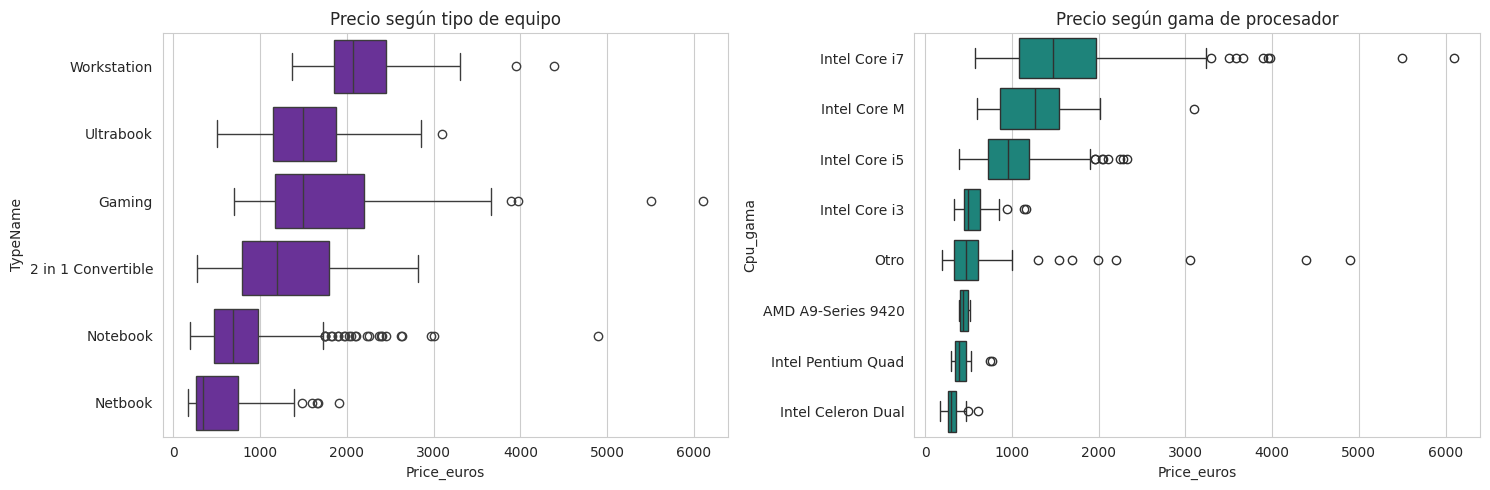

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden_tipo = df.groupby('TypeName')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='TypeName', data=df, order=orden_tipo, ax=axes[0], color='#6B21A8')
axes[0].set_title('Precio según tipo de equipo')

orden_cpu = df.groupby('Cpu_gama')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='Cpu_gama', data=df, order=orden_cpu, ax=axes[1], color='#0D9488')
axes[1].set_title('Precio según gama de procesador')

plt.tight_layout()
plt.show()

In [26]:
# las dos variables binarias
for columna in ['Touchscreen', 'IPS']:
    resumen = df.groupby(columna)['Price_euros'].agg(['count', 'mean', 'median'])
    diferencia = resumen.loc[1, 'median'] - resumen.loc[0, 'median']
    print(f"--- {columna} ---")
    print(resumen.round(0))
    print(f"Diferencia en la mediana: {diferencia:.0f} euros")
    print()

--- Touchscreen ---
             count    mean  median
Touchscreen                       
0             1111  1068.0   919.0
1              192  1445.0  1399.0
Diferencia en la mediana: 480 euros

--- IPS ---
     count    mean  median
IPS                       
0      938  1014.0   848.0
1      365  1406.0  1260.0
Diferencia en la mediana: 412 euros



### Qué nos dice esto

**Por tipo de equipo** hay diferencias grandes. Las Workstation tienen una mediana de
2.065 euros y los Netbook de 340. Los Notebook, que son la mayoría del catálogo (727 de
1.303), están en 691, o sea que son la gama de entrada.

**Por procesador** el orden es el que uno esperaría: i7 arriba (mediana 1.476), después
i5 (955), i3 (499) y los Celeron abajo (298). La progresión es bien clara.

**Por sistema operativo** los Mac son los más caros, pero hay que tener cuidado con esa
conclusión: son solo 21 equipos de 1.303. Con tan pocos casos el dato no es muy confiable.
Los Windows, con 1.125 equipos, sí son representativos.

**Las binarias** también muestran diferencia. Los equipos con pantalla táctil tienen una
mediana 480 euros más alta, y los que tienen panel IPS 412 euros más. Aunque acá vale
la pena aclarar que probablemente no es la pantalla en sí la que sube el precio, sino
que ese tipo de pantallas vienen en equipos de gama alta que ya son caros por otras
razones.

## 2.7 Hipótesis para la siguiente etapa

De todo lo anterior salen algunas ideas que la Etapa 3 puede probar con el modelo:

1. **La RAM y el SSD son los que más pesan en el precio.** Son las dos correlaciones más
   altas (0.74 y 0.67), así que deberían ser las variables más importantes del modelo.

2. **El tamaño de pantalla no sirve para predecir el precio,** pero el PPI sí (0.47).
   Lo que importa no es qué tan grande es la pantalla sino qué tan buena.

3. **El tipo de equipo y la gama del procesador son buenos separadores.** Las medianas
   entre categorías son muy distintas, o sea que agrupan bien.

4. **Cuidado con el disco duro.** Su correlación negativa no significa que abarate el
   equipo, sino que viene en equipos de gama baja. Meterlo al modelo sin entender esto
   puede llevar a interpretaciones equivocadas.

5. **La distribución del precio está sesgada.** Eso puede afectar a un modelo de regresión
   lineal, que asume cierta simetría en los errores. Podría valer la pena revisarlo.

## Resumen de la Etapa 2

Lo que hicimos:

- Calculamos media, mediana y moda, y vimos que en el precio la mediana representa
  mejor el valor típico porque la distribución está sesgada
- Medimos la dispersión con rango, varianza, desviación estándar y coeficiente de
  variación, que permite comparar variables con unidades distintas
- Analizamos la forma con asimetría y curtosis: casi todas las variables están
  estiradas hacia la derecha
- Detectamos outliers con el método del rango intercuartílico y decidimos conservarlos
  después de revisar que son equipos de gama alta reales, no errores
- Comparamos el precio contra todas las variables, numéricas y categóricas, y dejamos
  cinco hipótesis planteadas para el modelo

---

# ETAPA 3 — Visualización, modelo predictivo y storytelling

**A cargo de:** Andres Sebastian Quintana Morales

Contamos la historia que salió de los datos, armamos un modelo que predice el precio de
un portátil a partir de sus características, y planteamos para qué sirve en la práctica.

## 3.1 Librerías del modelo

Las de análisis ya están cargadas desde la Etapa 1; acá solo agregamos las de
scikit-learn.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Listo. Trabajamos con", df.shape[0], "equipos y", df.shape[1], "variables.")

Listo. Trabajamos con 1303 equipos y 18 variables.


---
# PARTE 1: La historia que cuentan los datos

## 3.2 El punto de partida

La pregunta era: ¿qué hace que un portátil sea caro?

La respuesta intuitiva sería el tamaño o la marca. Pero los datos dicen otra cosa.

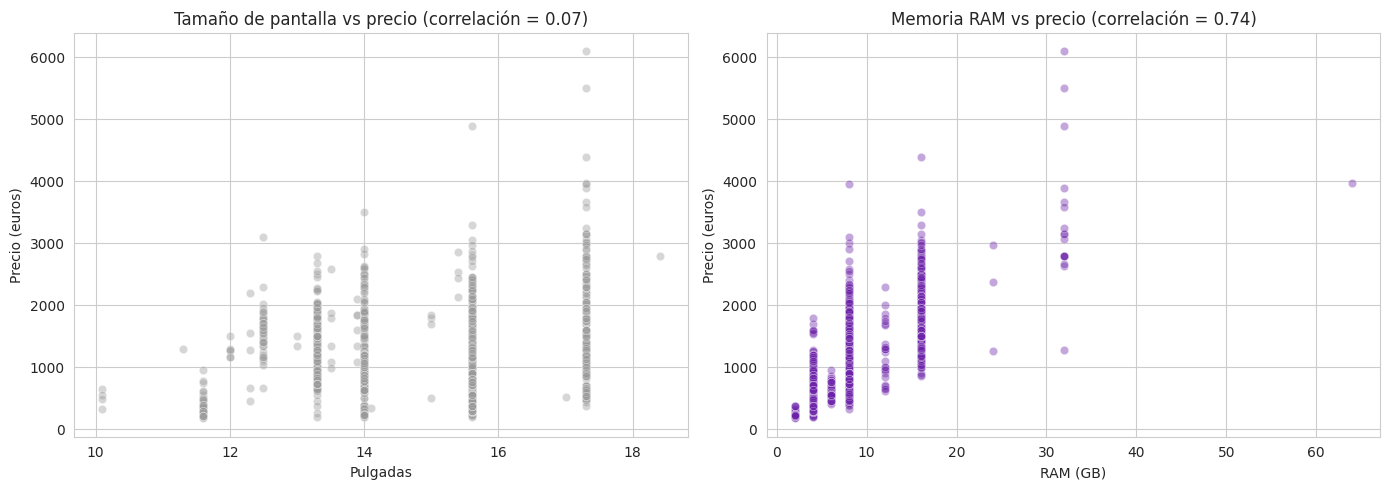

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# lo que uno pensaría que importa
sns.scatterplot(x='Inches', y='Price_euros', data=df, alpha=0.4, ax=axes[0], color='#999999')
axes[0].set_title(f'Tamaño de pantalla vs precio (correlación = {df.Inches.corr(df.Price_euros):.2f})')
axes[0].set_xlabel('Pulgadas')
axes[0].set_ylabel('Precio (euros)')

# lo que realmente importa
sns.scatterplot(x='Ram_GB', y='Price_euros', data=df, alpha=0.4, ax=axes[1], color='#6B21A8')
axes[1].set_title(f'Memoria RAM vs precio (correlación = {df.Ram_GB.corr(df.Price_euros):.2f})')
axes[1].set_xlabel('RAM (GB)')
axes[1].set_ylabel('Precio (euros)')

plt.tight_layout()
plt.show()

**El tamaño no dice nada.** La nube de puntos de la izquierda está completamente
dispersa: hay portátiles de 15.6 pulgadas que cuestan 300 euros y otros del mismo tamaño
que cuestan 4.000. La correlación es de apenas 0.07.

**La RAM sí.** A la derecha se ve una tendencia clara hacia arriba. La correlación es de
0.74, la más alta de todo el dataset.

Esto tiene sentido si uno lo piensa: el tamaño de la pantalla es una decisión de formato,
no de potencia. Un portátil grande puede ser barato porque es pesado y básico.

## 3.3 Lo que de verdad mueve el precio

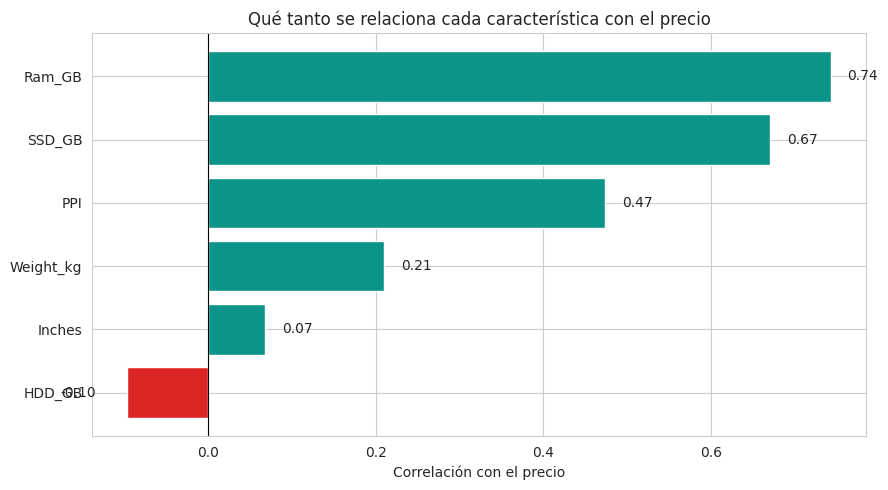

In [29]:
numericas = ['Ram_GB', 'SSD_GB', 'PPI', 'Weight_kg', 'Inches', 'HDD_GB']
corr = df[numericas + ['Price_euros']].corr()['Price_euros'].drop('Price_euros').sort_values()

plt.figure(figsize=(9, 5))
colores = ['#DC2626' if v < 0 else '#0D9488' for v in corr.values]
plt.barh(corr.index, corr.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Qué tanto se relaciona cada característica con el precio')
plt.xlabel('Correlación con el precio')
for i, v in enumerate(corr.values):
    plt.text(v + (0.02 if v > 0 else -0.08), i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()

Hay un dato que llama la atención: **el disco duro tiene correlación negativa**.

No es que un disco duro haga más barato al equipo. Es que los portátiles que todavía
traen HDD son los de gama de entrada, mientras que los caros vienen con SSD. La variable
está señalando el segmento, no causando el precio.

Es un buen recordatorio de que correlación no es causalidad.

## 3.4 Las gamas del mercado

Al agrupar por tipo de equipo aparece una segmentación bastante clara.

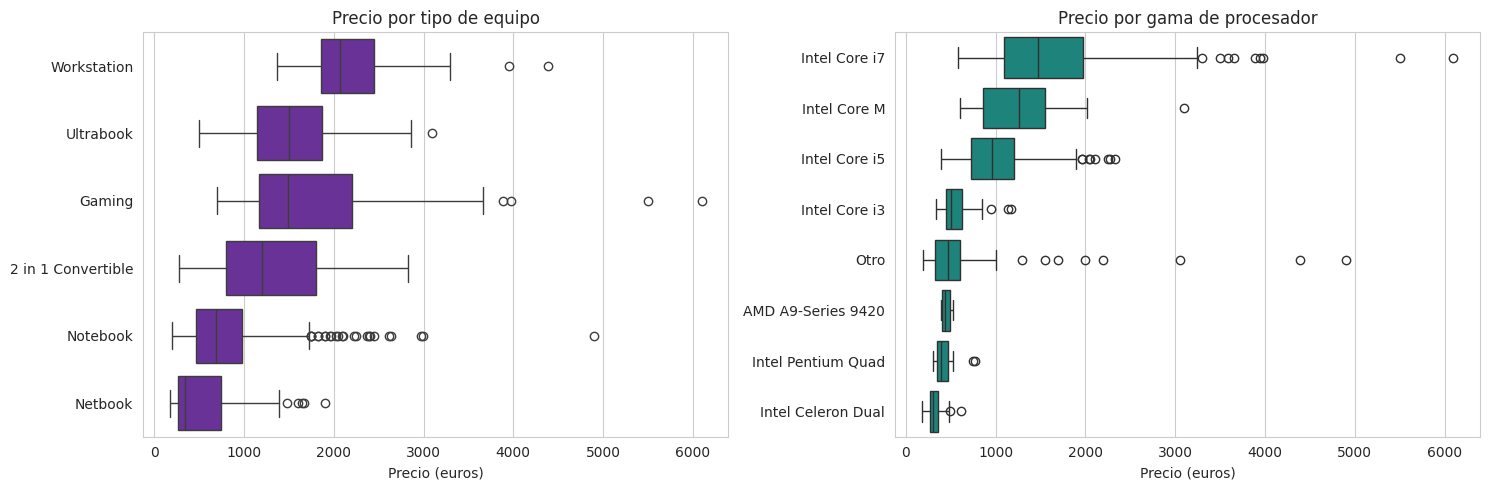

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = df.groupby('TypeName')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='TypeName', data=df, order=orden, ax=axes[0], color='#6B21A8')
axes[0].set_title('Precio por tipo de equipo')
axes[0].set_xlabel('Precio (euros)')
axes[0].set_ylabel('')

orden_cpu = df.groupby('Cpu_gama')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='Cpu_gama', data=df, order=orden_cpu, ax=axes[1], color='#0D9488')
axes[1].set_title('Precio por gama de procesador')
axes[1].set_xlabel('Precio (euros)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [31]:
resumen = df.groupby('TypeName')['Price_euros'].agg(['count', 'median']).sort_values('median', ascending=False)
resumen.columns = ['Equipos', 'Precio mediano']
print(resumen.round(0))

                    Equipos  Precio mediano
TypeName                                   
Workstation              29          2065.0
Ultrabook               196          1499.0
Gaming                  205          1493.0
2 in 1 Convertible      121          1199.0
Notebook                727           691.0
Netbook                  25           340.0


Las Workstation tienen una mediana de 2.065 euros y los Netbook de 340: seis veces de
diferencia. Y el procesador ordena el mercado casi perfecto, de i7 hacia abajo hasta los
Celeron.

Es decir, **el precio no depende de una sola cosa sino de un combo de características que
van juntas.** Un equipo con i7 normalmente también trae más RAM, SSD y mejor pantalla.
Por eso vale la pena construir un modelo que las considere todas al tiempo, en vez de
mirar variable por variable.

---
# PARTE 2: El modelo predictivo

## 3.5 Preparar los datos para el modelo

Acá hay un problema que resolver. Scikit-learn solo trabaja con números, pero varias de
nuestras variables son texto: la marca, el tipo de equipo, la gama del procesador.

No podemos simplemente asignarles números (Apple=1, Dell=2, HP=3) porque el modelo
interpretaría que HP es "mayor" que Apple, lo cual no significa nada.

La solución es el **one-hot encoding**: convertir cada categoría en su propia columna de
ceros y unos. Si un equipo es Ultrabook, la columna `TypeName_Ultrabook` vale 1 y todas
las demás columnas de tipo valen 0.

Usamos `drop_first=True` para eliminar una categoría de cada variable y evitar información
redundante: si un equipo no es ninguno de los otros tipos, ya sabemos cuál es.

In [32]:
numericas = ['Ram_GB', 'Weight_kg', 'Inches', 'PPI', 'SSD_GB', 'HDD_GB',
             'Flash_Storage_GB', 'Hybrid_GB', 'Touchscreen', 'IPS']
categoricas = ['Company', 'TypeName', 'Cpu_gama', 'Gpu_marca', 'SO']

X = pd.get_dummies(df[numericas + categoricas], columns=categoricas, drop_first=True)
y = df['Price_euros']

print("Columnas antes del encoding:", len(numericas + categoricas))
print("Columnas después del encoding:", X.shape[1])
print("\nEjemplo de columnas creadas:")
print([col for col in X.columns if col.startswith('TypeName_')])

Columnas antes del encoding: 15
Columnas después del encoding: 46

Ejemplo de columnas creadas:
['TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation']


## 3.6 Dividir en entrenamiento y prueba

Separamos el 80% de los datos para entrenar y guardamos el 20% para probar. Esto es
importante: si evaluáramos el modelo con los mismos datos que usó para aprender, el
resultado sería mentiroso. Lo que queremos saber es qué tan bien predice equipos que
nunca ha visto.

El `random_state=42` es para que la división sea siempre la misma y cualquiera pueda
reproducir estos resultados.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Equipos para entrenar:", len(X_train))
print("Equipos para probar:  ", len(X_test))

Equipos para entrenar: 1042
Equipos para probar:   261


## 3.7 Entrenar el modelo

Usamos regresión lineal múltiple. La idea es encontrar cuánto suma o resta al precio cada
característica, y sumarlo todo.

In [34]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Modelo entrenado.")
print("Intercepto:", round(modelo.intercept_, 2))

Modelo entrenado.
Intercepto: -231.03


## 3.8 ¿Qué tan bien predice?

Evaluamos con tres métricas:

- **R²**: qué porcentaje de la variación del precio logra explicar el modelo. Va de 0 a 1.
- **MAE**: en promedio, cuántos euros se equivoca.
- **RMSE**: parecido al MAE pero castiga más los errores grandes.

In [35]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   = {r2:.3f}")
print(f"MAE  = {mae:.0f} euros")
print(f"RMSE = {rmse:.0f} euros")
print()
print(f"El modelo explica el {r2*100:.1f}% de la variación del precio.")
print(f"En promedio se equivoca en {mae:.0f} euros sobre un precio mediano de {y.median():.0f}.")

R²   = 0.766
MAE  = 234 euros
RMSE = 345 euros

El modelo explica el 76.6% de la variación del precio.
En promedio se equivoca en 234 euros sobre un precio mediano de 977.


In [36]:
# comparamos contra el rendimiento en entrenamiento para ver si hay sobreajuste
print(f"R² en entrenamiento: {modelo.score(X_train, y_train):.3f}")
print(f"R² en prueba:        {r2:.3f}")

R² en entrenamiento: 0.780
R² en prueba:        0.766


Los dos R² son parecidos (0.78 contra 0.77), o sea que el modelo **no está sobreajustado**.
Si hubiera aprendido de memoria los datos de entrenamiento, el R² de prueba sería mucho
más bajo.

Un R² de 0.77 significa que las características técnicas explican tres cuartas partes de
la variación del precio. El cuarto restante son cosas que el dataset no captura: el
prestigio de la marca, el diseño, promociones, el momento en que se tomó el precio.

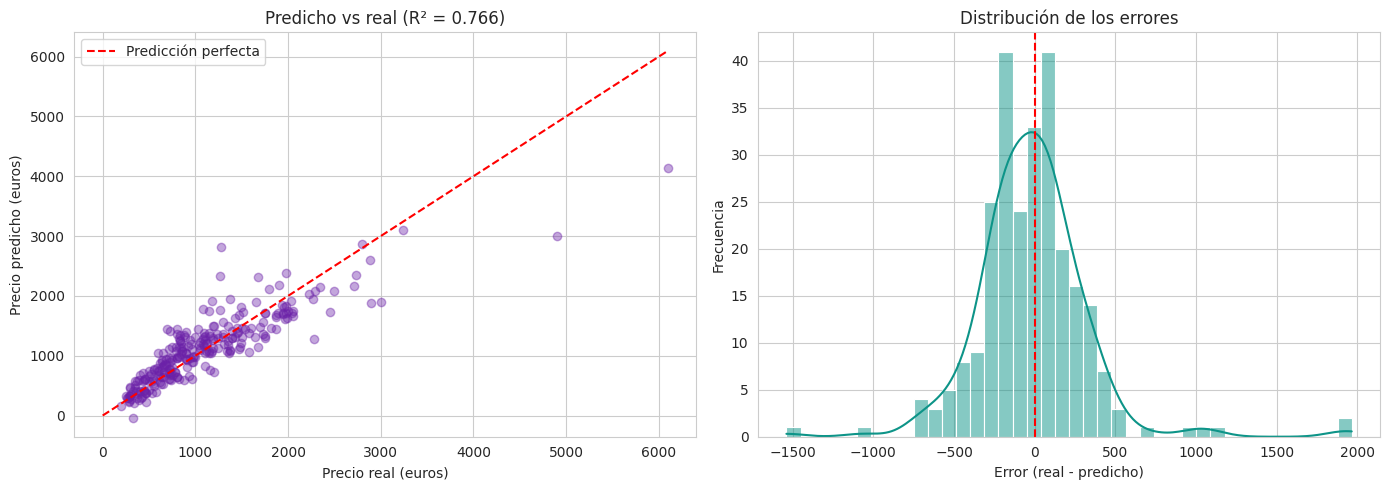

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicho vs real
axes[0].scatter(y_test, y_pred, alpha=0.4, color='#6B21A8')
lim = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', label='Predicción perfecta')
axes[0].set_xlabel('Precio real (euros)')
axes[0].set_ylabel('Precio predicho (euros)')
axes[0].set_title(f'Predicho vs real (R² = {r2:.3f})')
axes[0].legend()

# distribución de los errores
errores = y_test - y_pred
sns.histplot(errores, bins=40, kde=True, ax=axes[1], color='#0D9488')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Error (real - predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de los errores')

plt.tight_layout()
plt.show()

En el gráfico de la izquierda, mientras más pegados estén los puntos a la línea roja,
mejor predice. Se ve que funciona bien en el rango de 500 a 2.000 euros, donde está la
mayoría del catálogo, y se dispersa en los equipos muy caros: hay pocos de esos y el
modelo tuvo menos con qué aprender.

Los errores están centrados en cero, que es lo que uno quiere: el modelo no se equivoca
sistemáticamente hacia arriba ni hacia abajo.

## 3.9 Qué aprendió el modelo

Los coeficientes dicen cuánto suma o resta cada característica al precio, manteniendo
todo lo demás igual.

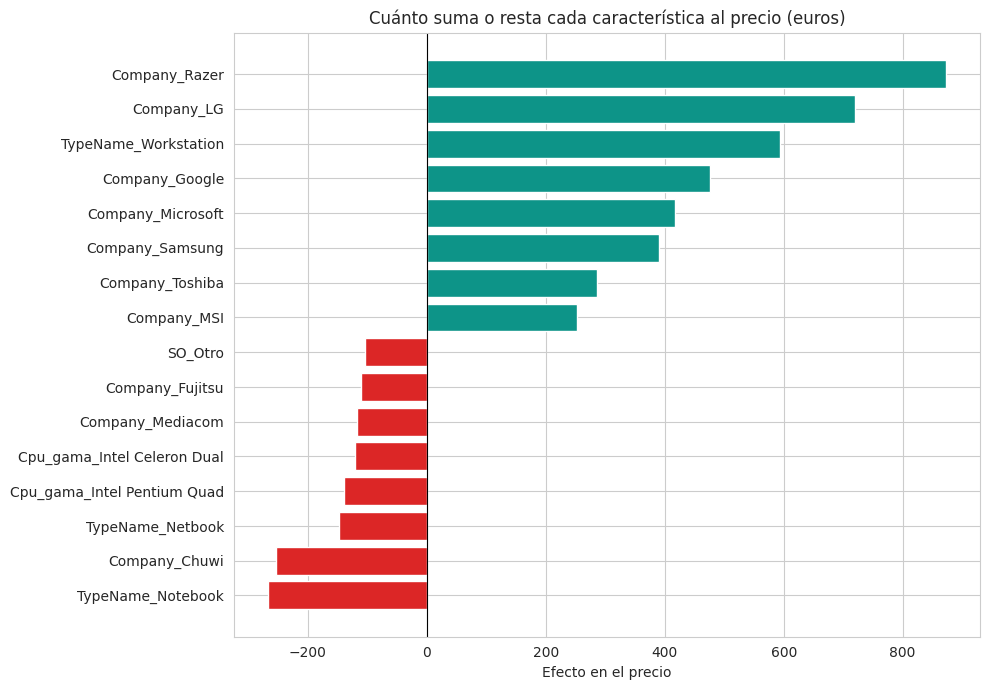

In [38]:
coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values()

top = pd.concat([coeficientes.head(8), coeficientes.tail(8)])

plt.figure(figsize=(10, 7))
colores = ['#DC2626' if v < 0 else '#0D9488' for v in top.values]
plt.barh(top.index, top.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Cuánto suma o resta cada característica al precio (euros)')
plt.xlabel('Efecto en el precio')
plt.tight_layout()
plt.show()

In [39]:
print("--- Lo que más encarece ---")
print(coeficientes.tail(6).round(0).to_string())
print("\n--- Lo que más abarata ---")
print(coeficientes.head(6).round(0).to_string())
print("\n--- Efecto de las numéricas ---")
for v in ['Ram_GB', 'SSD_GB', 'PPI', 'Weight_kg']:
    print(f"{v:12s} {coeficientes[v]:+8.1f} euros por unidad")

--- Lo que más encarece ---
Company_Samsung         391.0
Company_Microsoft       417.0
Company_Google          476.0
TypeName_Workstation    594.0
Company_LG              719.0
Company_Razer           873.0

--- Lo que más abarata ---
TypeName_Notebook             -267.0
Company_Chuwi                 -254.0
TypeName_Netbook              -148.0
Cpu_gama_Intel Pentium Quad   -139.0
Cpu_gama_Intel Celeron Dual   -121.0
Company_Mediacom              -117.0

--- Efecto de las numéricas ---
Ram_GB          +45.5 euros por unidad
SSD_GB           +0.7 euros por unidad
PPI              +2.4 euros por unidad
Weight_kg      +237.2 euros por unidad


Cada GB de RAM adicional suma unos euros al precio, cada GB de SSD también, y el PPI
tiene un efecto claro. Del lado de las marcas, Razer y LG son las que más encarecen
respecto a la marca base, y ser Workstation suma bastante.

Ojo con interpretar esto como causa. El modelo dice que los equipos Razer son más caros
en promedio una vez descontadas las demás características, no que ponerle el logo de
Razer a un portátil lo encarezca.

## 3.10 Probando el modelo con un caso concreto

Para que se entienda mejor, veamos qué predice para un equipo específico del conjunto
de prueba.

In [40]:
i = 5
equipo = X_test.iloc[[i]]
real = y_test.iloc[i]
predicho = modelo.predict(equipo)[0]

# recuperamos las características originales de ese equipo
idx = X_test.index[i]
print("Equipo:", df.loc[idx, 'Company'], "|", df.loc[idx, 'TypeName'])
print("RAM:", df.loc[idx, 'Ram_GB'], "GB | SSD:", df.loc[idx, 'SSD_GB'], "GB")
print("Procesador:", df.loc[idx, 'Cpu_gama'])
print()
print(f"Precio real:     {real:.0f} euros")
print(f"Precio predicho: {predicho:.0f} euros")
print(f"Diferencia:      {abs(real - predicho):.0f} euros")

Equipo: HP | 2 in 1 Convertible
RAM: 8 GB | SSD: 256.0 GB
Procesador: Intel Core i5

Precio real:     1399 euros
Precio predicho: 1295 euros
Diferencia:      104 euros


---
# PARTE 3: Conclusiones y aplicación

## 3.11 Qué encontramos

**1. Las características técnicas explican el 77% del precio.** No es todo, pero es la
mayor parte. Existe una lógica bastante consistente en cómo se fijan los precios en este
mercado.

**2. La RAM y el almacenamiento SSD son los que más pesan.** Fueron las correlaciones más
altas y también los coeficientes más consistentes del modelo.

**3. El tamaño de pantalla es irrelevante, la calidad no.** Las pulgadas tienen correlación
de 0.07 con el precio, pero el PPI tiene 0.47. Lo que se paga no es una pantalla grande
sino una pantalla buena.

**4. El mercado está segmentado en gamas claras.** De Netbook a Workstation hay seis veces
de diferencia en el precio mediano, y el procesador ordena el mercado casi perfectamente.

**5. El modelo se equivoca en promedio 234 euros.** Sobre un precio mediano de 977, es un
error de alrededor del 24%. Sirve para estimar rangos, no para poner precios exactos.

## 3.12 Para qué sirve esto en la práctica

Un modelo así tiene usos concretos en el área de tecnología:

**Compras corporativas.** Cuando una empresa cotiza equipos para su personal, este modelo
permite estimar cuánto debería costar un portátil con determinadas especificaciones. Si un
proveedor cotiza muy por encima de la predicción, hay margen para negociar. Si cotiza muy
por debajo, vale la pena revisar por qué.

**Detección de oportunidades.** Los equipos cuyo precio real está muy por debajo del
predicho son candidatos a ser buenas compras: tienen mejores especificaciones de lo que su
precio sugiere.

**Definición de presupuestos.** En lugar de pedir un presupuesto genérico, se puede
justificar con datos: "un equipo con 16 GB de RAM y SSD de 512 para el área de desarrollo
debería costar alrededor de X euros".

**Lo que el modelo no puede hacer.** No sirve para predecir precios de equipos muy fuera
del rango del dataset, ni captura el efecto del tiempo (los precios de tecnología bajan),
ni incluye factores como garantía o servicio postventa, que en compras corporativas pesan
bastante.

## 3.13 Limitaciones

Para ser honestos con el alcance de este trabajo:

- El dataset es una foto de un momento, no una serie de tiempo. No sabemos de cuándo son
  los precios ni cómo han cambiado.
- La regresión lineal asume que las relaciones son lineales. Probablemente no lo son del
  todo: pasar de 4 a 8 GB de RAM no cuesta lo mismo que pasar de 32 a 64.
- Algunas categorías tienen muy pocos equipos (21 Mac, 12 con procesador AMD A9), así que
  sus coeficientes no son muy confiables.
- Los precios están en euros y corresponden a un mercado que no necesariamente se comporta
  igual que el colombiano.

## Resumen de la Etapa 3

Lo que hicimos:

- Visualizamos la relación entre las características y el precio, encontrando que la
  intuición sobre el tamaño de pantalla estaba equivocada
- Convertimos las variables categóricas a formato numérico con one-hot encoding, pasando
  de 15 a 46 columnas
- Entrenamos una regresión lineal múltiple con división 80/20
- Obtuvimos R² de 0.77 y error promedio de 234 euros, sin sobreajuste
- Interpretamos los coeficientes para entender qué aprendió el modelo
- Planteamos aplicaciones concretas y fuimos explícitos sobre las limitaciones

---

# Cierre del proyecto

## El recorrido completo

**Etapa 1.** El dataset no tenía valores nulos ni duplicados, pero diez de sus trece
columnas eran texto sin procesar. La RAM decía `"8GB"`, el peso decía `"1.37kg"`, y el
almacenamiento mezclaba unidades y hasta dos discos en un mismo campo. El trabajo de
limpieza consistió en convertir todo eso en información utilizable: quedamos con 18
variables y los 1.303 equipos intactos.

**Etapa 2.** El precio resultó estar sesgado hacia la derecha (asimetría de 1.52), así
que la mediana representa mejor el valor típico que el promedio. El método del rango
intercuartílico marcó 221 equipos como atípicos por RAM, pero al revisarlos eran
portátiles Gaming y Workstation reales, no errores, así que los conservamos. La RAM y el
SSD aparecieron como las variables más relacionadas con el precio.

**Etapa 3.** Convertimos las variables categóricas a formato numérico y entrenamos una
regresión lineal múltiple. El modelo explica el 76.6% de la variación del precio con un
error promedio de 234 euros, sin señales de sobreajuste.

## La respuesta a la pregunta

Sí se puede predecir el precio de un portátil a partir de sus especificaciones, con
bastante precisión para estimar rangos aunque no para fijar precios exactos.

Lo que más pesa es la memoria RAM y el almacenamiento SSD. Lo que no pesa, contra lo que
uno pensaría, es el tamaño de la pantalla: lo que se paga no es una pantalla grande sino
una pantalla buena.

## Qué aprendimos haciendo esto

Que la mayor parte del trabajo en ciencia de datos no está en el modelo sino antes. La
Etapa 1 fue la más larga y la menos vistosa, pero sin ella no había nada que analizar.

Y que los números hay que interpretarlos, no solo calcularlos. El disco duro tiene
correlación negativa con el precio y el peso aparece sumando euros en el modelo; ninguna
de las dos cosas significa lo que parece a primera vista.